In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, Point
import numpy as np

In [3]:
data = pd.read_csv('./data/location.csv')

data.head()

,sampno,locno,perno,loctype,state,country,state_fips,county_fips,tract_fips,out_region,home,latitude,longitude
0,20000083,10000,-1,1,IL,USA,17,31,802403,0,1,42.141870,-87.953126
1,20000083,10002,1,2,IL,USA,17,31,801601,0,0,42.145289,-87.863023
2,20000083,10401,-1,4,IL,USA,17,31,801606,0,0,42.116325,-87.868708
3,20000083,10402,-1,4,IL,USA,17,31,803007,0,0,42.131743,-87.970674
4,20000083,10403,-1,4,IL,USA,17,31,802504,0,0,42.134326,-87.937060


In [4]:
data = pd.read_csv('./data/location.csv')


data = data.loc[(data.loctype == 1) | (data.loctype == 2) | (data.loctype == 3)]

v = data.sampno.value_counts()

data = data[data.sampno.apply(lambda x: v[x] > 1)]

data

,sampno,locno,perno,loctype,state,country,state_fips,county_fips,tract_fips,out_region,home,latitude,longitude
0,20000083,10000,-1,1,IL,USA,17,31,802403,0,1,42.141870,-87.953126
1,20000083,10002,1,2,IL,USA,17,31,801601,0,0,42.145289,-87.863023
11,20000136,10000,-1,1,IL,USA,17,31,81402,0,1,41.891022,-87.612931
12,20000136,10002,1,2,IL,USA,17,31,830900,0,0,41.928424,-87.684906
17,20000136,20002,2,2,IL,USA,17,31,81401,0,0,41.895035,-87.619717
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110062,70100988,20003,2,3,IL,USA,17,31,281900,0,0,41.878635,-87.642924
110071,70100992,10000,-1,1,IL,USA,17,97,864519,0,1,42.165420,-87.959139
110072,70100992,10002,1,2,IL,USA,17,97,864205,0,0,42.292549,-88.141232
110074,70100993,10000,-1,1,IL,USA,17,31,260700,0,1,41.877056,-87.727996


In [18]:
import tqdm

In [31]:
tracts = gpd.read_file('osmnx/data/tracts.geojson')

tract_sampno = [None for i in range(len(data.index))]

for i in tqdm.tqdm(range(len(data.index))):
    s = data.iloc[i]
    for row in tracts.iloc:
        if row.geometry.contains(Point(s.longitude, s.latitude)):
            tract_sampno[i] = row.namelsad10
            break
            

data

100%|██████████| 32922/32922 [19:50<00:00, 27.66it/s]


,sampno,locno,perno,loctype,state,country,state_fips,county_fips,tract_fips,out_region,home,latitude,longitude,tract
0,20000083,10000,-1,1,IL,USA,17,31,802403,0,1,42.141870,-87.953126,0.0
1,20000083,10002,1,2,IL,USA,17,31,801601,0,0,42.145289,-87.863023,0.0
11,20000136,10000,-1,1,IL,USA,17,31,81402,0,1,41.891022,-87.612931,0.0
12,20000136,10002,1,2,IL,USA,17,31,830900,0,0,41.928424,-87.684906,0.0
17,20000136,20002,2,2,IL,USA,17,31,81401,0,0,41.895035,-87.619717,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110062,70100988,20003,2,3,IL,USA,17,31,281900,0,0,41.878635,-87.642924,0.0
110071,70100992,10000,-1,1,IL,USA,17,97,864519,0,1,42.165420,-87.959139,0.0
110072,70100992,10002,1,2,IL,USA,17,97,864205,0,0,42.292549,-88.141232,0.0
110074,70100993,10000,-1,1,IL,USA,17,31,260700,0,1,41.877056,-87.727996,0.0


In [ ]:
data['tract'] = tract_sampno

In [13]:
filtered = pd.DataFrame(columns=data.columns)

for s in data.sampno.unique():
    snip = data.loc[data.sampno == s]
    if True in [pd.isna(x) for x in list(snip.tract)]: continue
    
    if not len(filtered.index): filtered = snip
    else: filtered = pd.concat([filtered, snip])

filtered.to_csv('./data/tract_location.csv')
filtered.head()

,Unnamed: 0.1,Unnamed: 0,sampno,locno,perno,loctype,state,country,state_fips,county_fips,tract_fips,out_region,home,latitude,longitude,tract
2,2,11,20000136,10000,-1,1,IL,USA,17,31,81402,0,1,41.891022,-87.612931,Census Tract 814.02
3,3,12,20000136,10002,1,2,IL,USA,17,31,830900,0,0,41.928424,-87.684906,Census Tract 8309
4,4,17,20000136,20002,2,2,IL,USA,17,31,81401,0,0,41.895035,-87.619717,Census Tract 814.01
5,5,35,20000300,10000,-1,1,IL,USA,17,31,81300,0,1,41.898335,-87.620753,Census Tract 813
6,6,36,20000300,10002,1,2,IL,USA,17,31,281900,0,0,41.878635,-87.642924,Census Tract 2819


In [7]:
data = pd.read_csv('./data/tract_location.csv')
data = data.drop([col for col in data.columns if "Unnamed" in col], axis=1)
data.head()

,sampno,locno,perno,loctype,state,country,state_fips,county_fips,tract_fips,out_region,home,latitude,longitude,tract
0,20000136,10000,-1,1,IL,USA,17,31,81402,0,1,41.891022,-87.612931,Census Tract 814.02
1,20000136,10002,1,2,IL,USA,17,31,830900,0,0,41.928424,-87.684906,Census Tract 8309
2,20000136,20002,2,2,IL,USA,17,31,81401,0,0,41.895035,-87.619717,Census Tract 814.01
3,20000300,10000,-1,1,IL,USA,17,31,81300,0,1,41.898335,-87.620753,Census Tract 813
4,20000300,10002,1,2,IL,USA,17,31,281900,0,0,41.878635,-87.642924,Census Tract 2819


In [8]:
households = pd.read_csv('./data/household.csv')

households.head()

,sampno,travdate,travday,hhsize,hhveh,transprob,transprob_o,hlive,restylast,restylast_o,...,incendonate,resty,resty_o,hhinc,download,source,source_o,hhtrips,phase,wthhfin
0,20000083,2017-10-11,4,1,1,-9,-1,2,3,-1,...,-9,3,-1,7,2,-1,-1,9,1,155.2391
1,20000136,2017-10-23,2,3,1,-9,-1,1,2,-1,...,-9,3,-1,9,2,-1,-1,4,1,319.6422
2,20000228,2017-10-01,2,1,1,-9,-1,10,-1,-1,...,-9,1,-1,10,2,-1,-1,9,1,540.4961
3,20000248,2017-09-21,5,3,1,-9,-1,26,-1,-1,...,-9,3,-1,1,2,-1,-1,4,1,662.6029
4,20000300,2017-09-13,4,1,0,-9,-1,8,-1,-1,...,-9,3,-1,6,1,-1,-1,2,1,68.7010


In [9]:
data = pd.merge(data, households[['wthhfin', 'sampno']], on='sampno', how='inner')

data.head()

,sampno,locno,perno,loctype,state,country,state_fips,county_fips,tract_fips,out_region,home,latitude,longitude,tract,wthhfin
0,20000136,10000,-1,1,IL,USA,17,31,81402,0,1,41.891022,-87.612931,Census Tract 814.02,319.6422
1,20000136,10002,1,2,IL,USA,17,31,830900,0,0,41.928424,-87.684906,Census Tract 8309,319.6422
2,20000136,20002,2,2,IL,USA,17,31,81401,0,0,41.895035,-87.619717,Census Tract 814.01,319.6422
3,20000300,10000,-1,1,IL,USA,17,31,81300,0,1,41.898335,-87.620753,Census Tract 813,68.7010
4,20000300,10002,1,2,IL,USA,17,31,281900,0,0,41.878635,-87.642924,Census Tract 2819,68.7010


In [10]:
sampnos = data.sampno.unique()

origin_dest_pairs_weights = {}

for i, s in enumerate(sampnos):
    origin = list(data.loc[(data.sampno == s) & (data.home == 1)].tract)[0]
    destinations = data.loc[(data.sampno == s) & (data.home == 0)]

    if not i: print(destinations)
    origin_dest_pairs_weights.setdefault(origin, {})

    for d in destinations.iloc:
        if not d.tract in origin_dest_pairs_weights[origin]:
            origin_dest_pairs_weights[origin][d.tract] = d.wthhfin
        else:
            origin_dest_pairs_weights[origin][d.tract] += d.wthhfin

     sampno  locno  perno  loctype state country  state_fips  county_fips  \
1  20000136  10002      1        2    IL     USA          17           31   
2  20000136  20002      2        2    IL     USA          17           31   

   tract_fips  out_region  home   latitude  longitude                tract  \
1      830900           0     0  41.928424 -87.684906    Census Tract 8309   
2       81401           0     0  41.895035 -87.619717  Census Tract 814.01   

    wthhfin  
1  319.6422  
2  319.6422  


In [11]:
import json

json.dump(origin_dest_pairs_weights, open('data/origin_dest_weights.json', 'w'), indent=2)

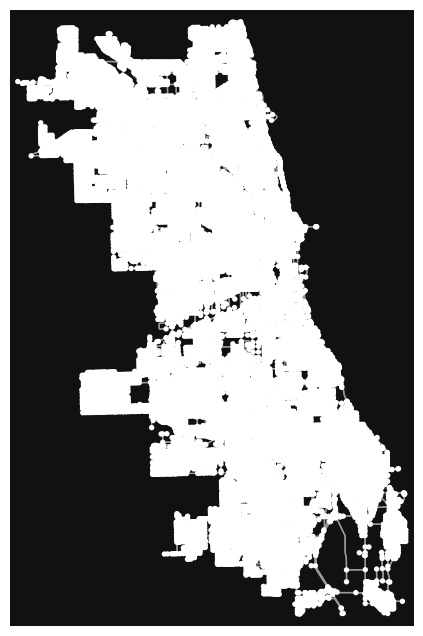

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import networkx as nx
import numpy as np
import json
import osmnx as ox

## IMPORT CITY
city = ox.graph_from_place('Chicago, IL, USA', network_type='drive')

In [2]:
tract_centroids = json.load(open('./data/tract-centroids.json'))

nodes = {tract: ox.nearest_nodes(city, lon, lat) for tract, (lon, lat) in tract_centroids.items()}

In [7]:
json.dump(nodes, open('data/tract-node#.json', 'w'), indent=2)

In [10]:
origin_pairs = json.load(open(f'./data/origin_pairs.json'))

origin_tract = "Census Tract 814.02"

for dest_tract in np.unique(origin_pairs[origin_tract]):
    print(dest_tract)

Census Tract 814.01
Census Tract 814.03
Census Tract 8309
Census Tract 8391
Census Tract 8419
Census Tract 8420


In [27]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, Point
import numpy as np

data = pd.read_csv('./analysis/weighted.csv')

data = data.set_index(data.columns[0])

import json

weights = json.load(open('data/origin_dest_weights.json', 'r'))

col = np.zeros(len(data.index))

for i, row in enumerate(data.iloc):
    if not row.name in data.index: continue
    col[i] = sum([w for k, w in weights[row.name].items()])

data['flow_weight'] = col

In [29]:
data.to_csv('./analysis/weighted.csv')